# Traffic Demand Prediction

## Objective
The goal of this project is to predict normalized traffic demand using temporal, geospatial and road infrastructure information.

Evaluation Metric:
R² Score

Approach:
1. Data Cleaning
2. Exploratory Data Analysis
3. Feature Engineering
4. Model Training
5. Hyperparameter Optimization
6. Ensemble Learning
7. Final Submission Generation

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

Training and test datasets were loaded and inspected to understand feature types, missing values and overall structure.


In [ ]:
df = pd.read_csv('/content/train.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  object 
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  object 
 8   Landmarks      77299 non-null  object 
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 6.5+ MB


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


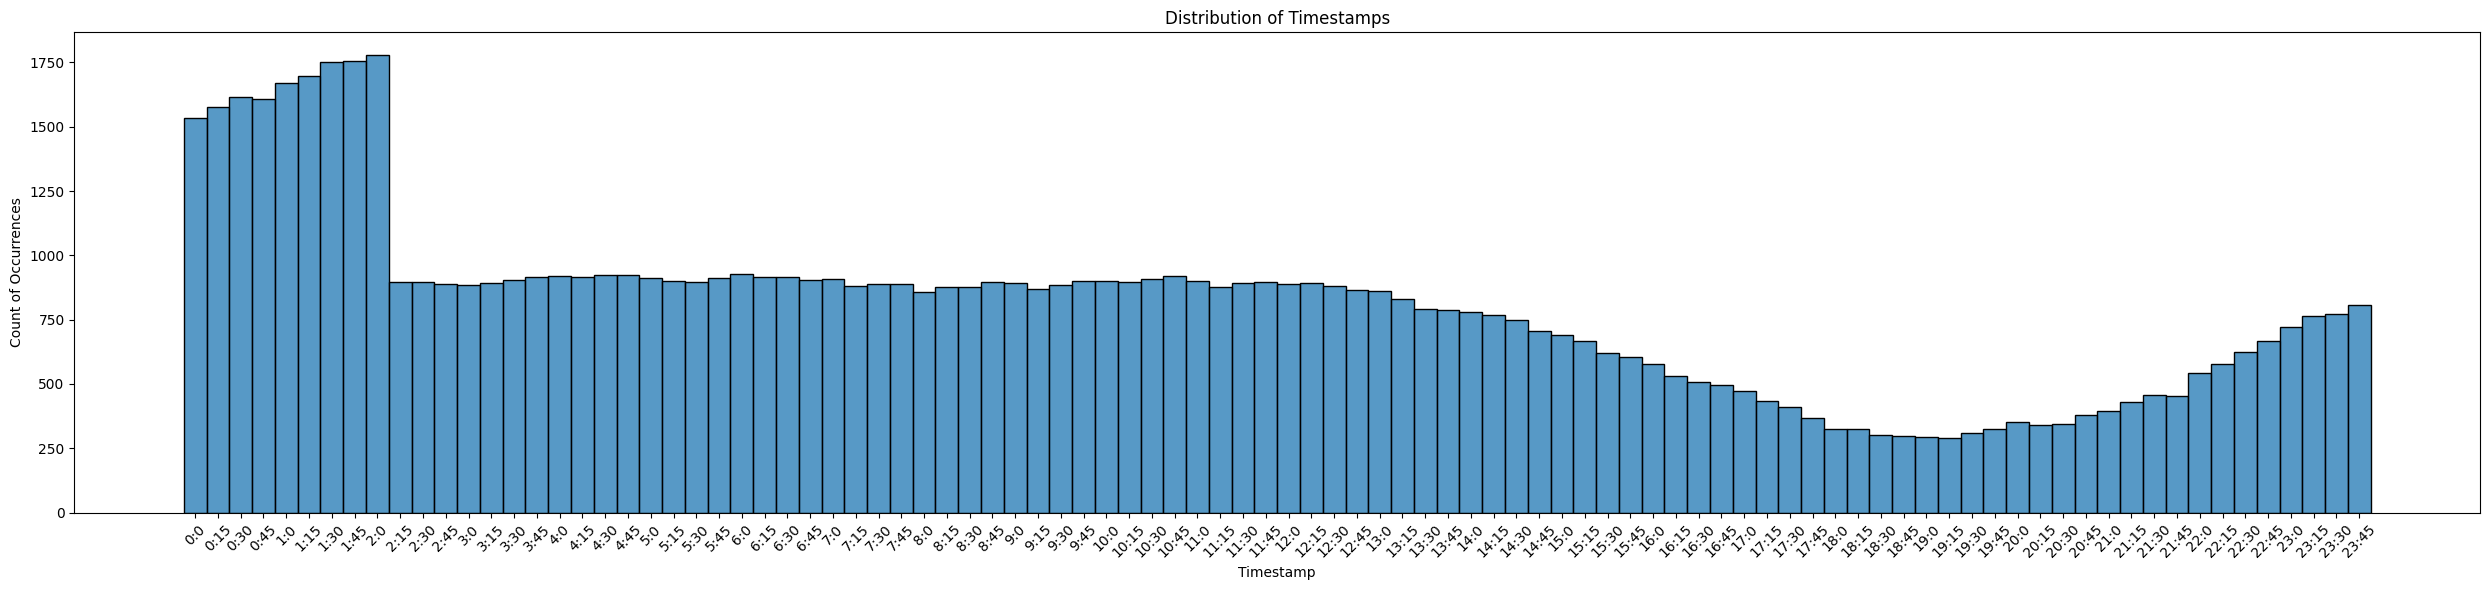

In [ ]:
plt.figure(figsize=(25, 6))
sns.histplot(x=df['timestamp'], kde=False, bins=50)
plt.title('Distribution of Timestamps')
plt.xlabel('Timestamp')
plt.ylabel('Count of Occurrences')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Data Cleaning & Preprocessing

The dataset was checked for:
- Missing values
- Duplicate records
- Invalid timestamps
- Data type consistency

Missing values were imputed using appropriate statistical techniques.

In [ ]:
print("Missing values before cleaning:\n", df.isnull().sum())


df['Temperature'] = df['Temperature'].fillna(df['Temperature'].mean())
df['RoadType'] = df['RoadType'].fillna(df['RoadType'].mode()[0])
df['Weather'] = df['Weather'].fillna(df['Weather'].mode()[0])

print("\nMissing values after filling:\n", df.isnull().sum())

print("\nNumber of duplicate rows before dropping:", df.duplicated().sum())
df = df.drop_duplicates()
print("Number of duplicate rows after dropping:", df.duplicated().sum())

print("\nDataFrame head after initial cleaning:")
display(df.head())

Missing values before cleaning:
 Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64

Missing values after filling:
 Index            0
geohash          0
day              0
timestamp        0
demand           0
RoadType         0
NumberofLanes    0
LargeVehicles    0
Landmarks        0
Temperature      0
Weather          0
dtype: int64

Number of duplicate rows before dropping: 0
Number of duplicate rows after dropping: 0

DataFrame head after initial cleaning:


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,Residential,1,Not Allowed,No,16.405354,Sunny
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,16.405354,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [ ]:
df.shape

(77299, 11)

In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"], format="%H:%M")

df["hour"] = df["timestamp"].dt.hour
df["minute"] = df["timestamp"].dt.minute

print("DataFrame info after processing 'timestamp':")
df.info()
print("\nDataFrame head after processing 'timestamp':")
display(df.head())

DataFrame info after processing 'timestamp':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Index          77299 non-null  int64         
 1   geohash        77299 non-null  object        
 2   day            77299 non-null  int64         
 3   timestamp      77299 non-null  datetime64[ns]
 4   demand         77299 non-null  float64       
 5   RoadType       77299 non-null  object        
 6   NumberofLanes  77299 non-null  int64         
 7   LargeVehicles  77299 non-null  object        
 8   Landmarks      77299 non-null  object        
 9   Temperature    77299 non-null  float64       
 10  Weather        77299 non-null  object        
 11  hour           77299 non-null  int32         
 12  minute         77299 non-null  int32         
dtypes: datetime64[ns](1), float64(2), int32(2), int64(3), object(5)
memory usage

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute
0,0,qp02z1,48,1900-01-01,0.048804,Residential,1,Not Allowed,No,16.405354,Sunny,0,0
1,1,qp02zt,48,1900-01-01,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny,0,0
2,2,qp08bj,48,1900-01-01,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny,0,0
3,3,qp08gt,48,1900-01-01,0.003272,Residential,1,Not Allowed,No,16.405354,Rainy,0,0
4,4,qp02zq,48,1900-01-01,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy,0,0


## Statistical Summary

Basic descriptive statistics were generated to understand the distribution and scale of numerical variables.

In [ ]:
df.describe()

,Index,day,timestamp,demand,NumberofLanes,Temperature,hour,minute
count,77299.000000,77299.000000,77299,7.729900e+04,77299.000000,77299.000000,77299.000000,77299.000000
mean,38649.000000,48.101838,1900-01-01 09:28:21.126792960,9.394238e-02,2.014334,16.405354,9.101347,22.271310
min,0.000000,48.000000,1900-01-01 00:00:00,6.245650e-07,1.000000,-14.935097,0.000000,0.000000
25%,19324.500000,48.000000,1900-01-01 03:15:00,1.822723e-02,1.000000,11.624189,3.000000,0.000000
50%,38649.000000,48.000000,1900-01-01 08:45:00,4.775994e-02,2.000000,16.405354,8.000000,15.000000
75%,57973.500000,48.000000,1900-01-01 14:15:00,1.085951e-01,3.000000,21.115592,14.000000,30.000000
max,77298.000000,49.000000,1900-01-01 23:45:00,1.000000e+00,5.000000,48.251433,23.000000,45.000000
std,22314.443566,0.302438,NaN,1.421905e-01,0.904665,7.240082,6.856045,16.853641


## Exploratory Data Analysis (EDA)

EDA was performed to understand relationships between variables and identify important factors affecting traffic demand.

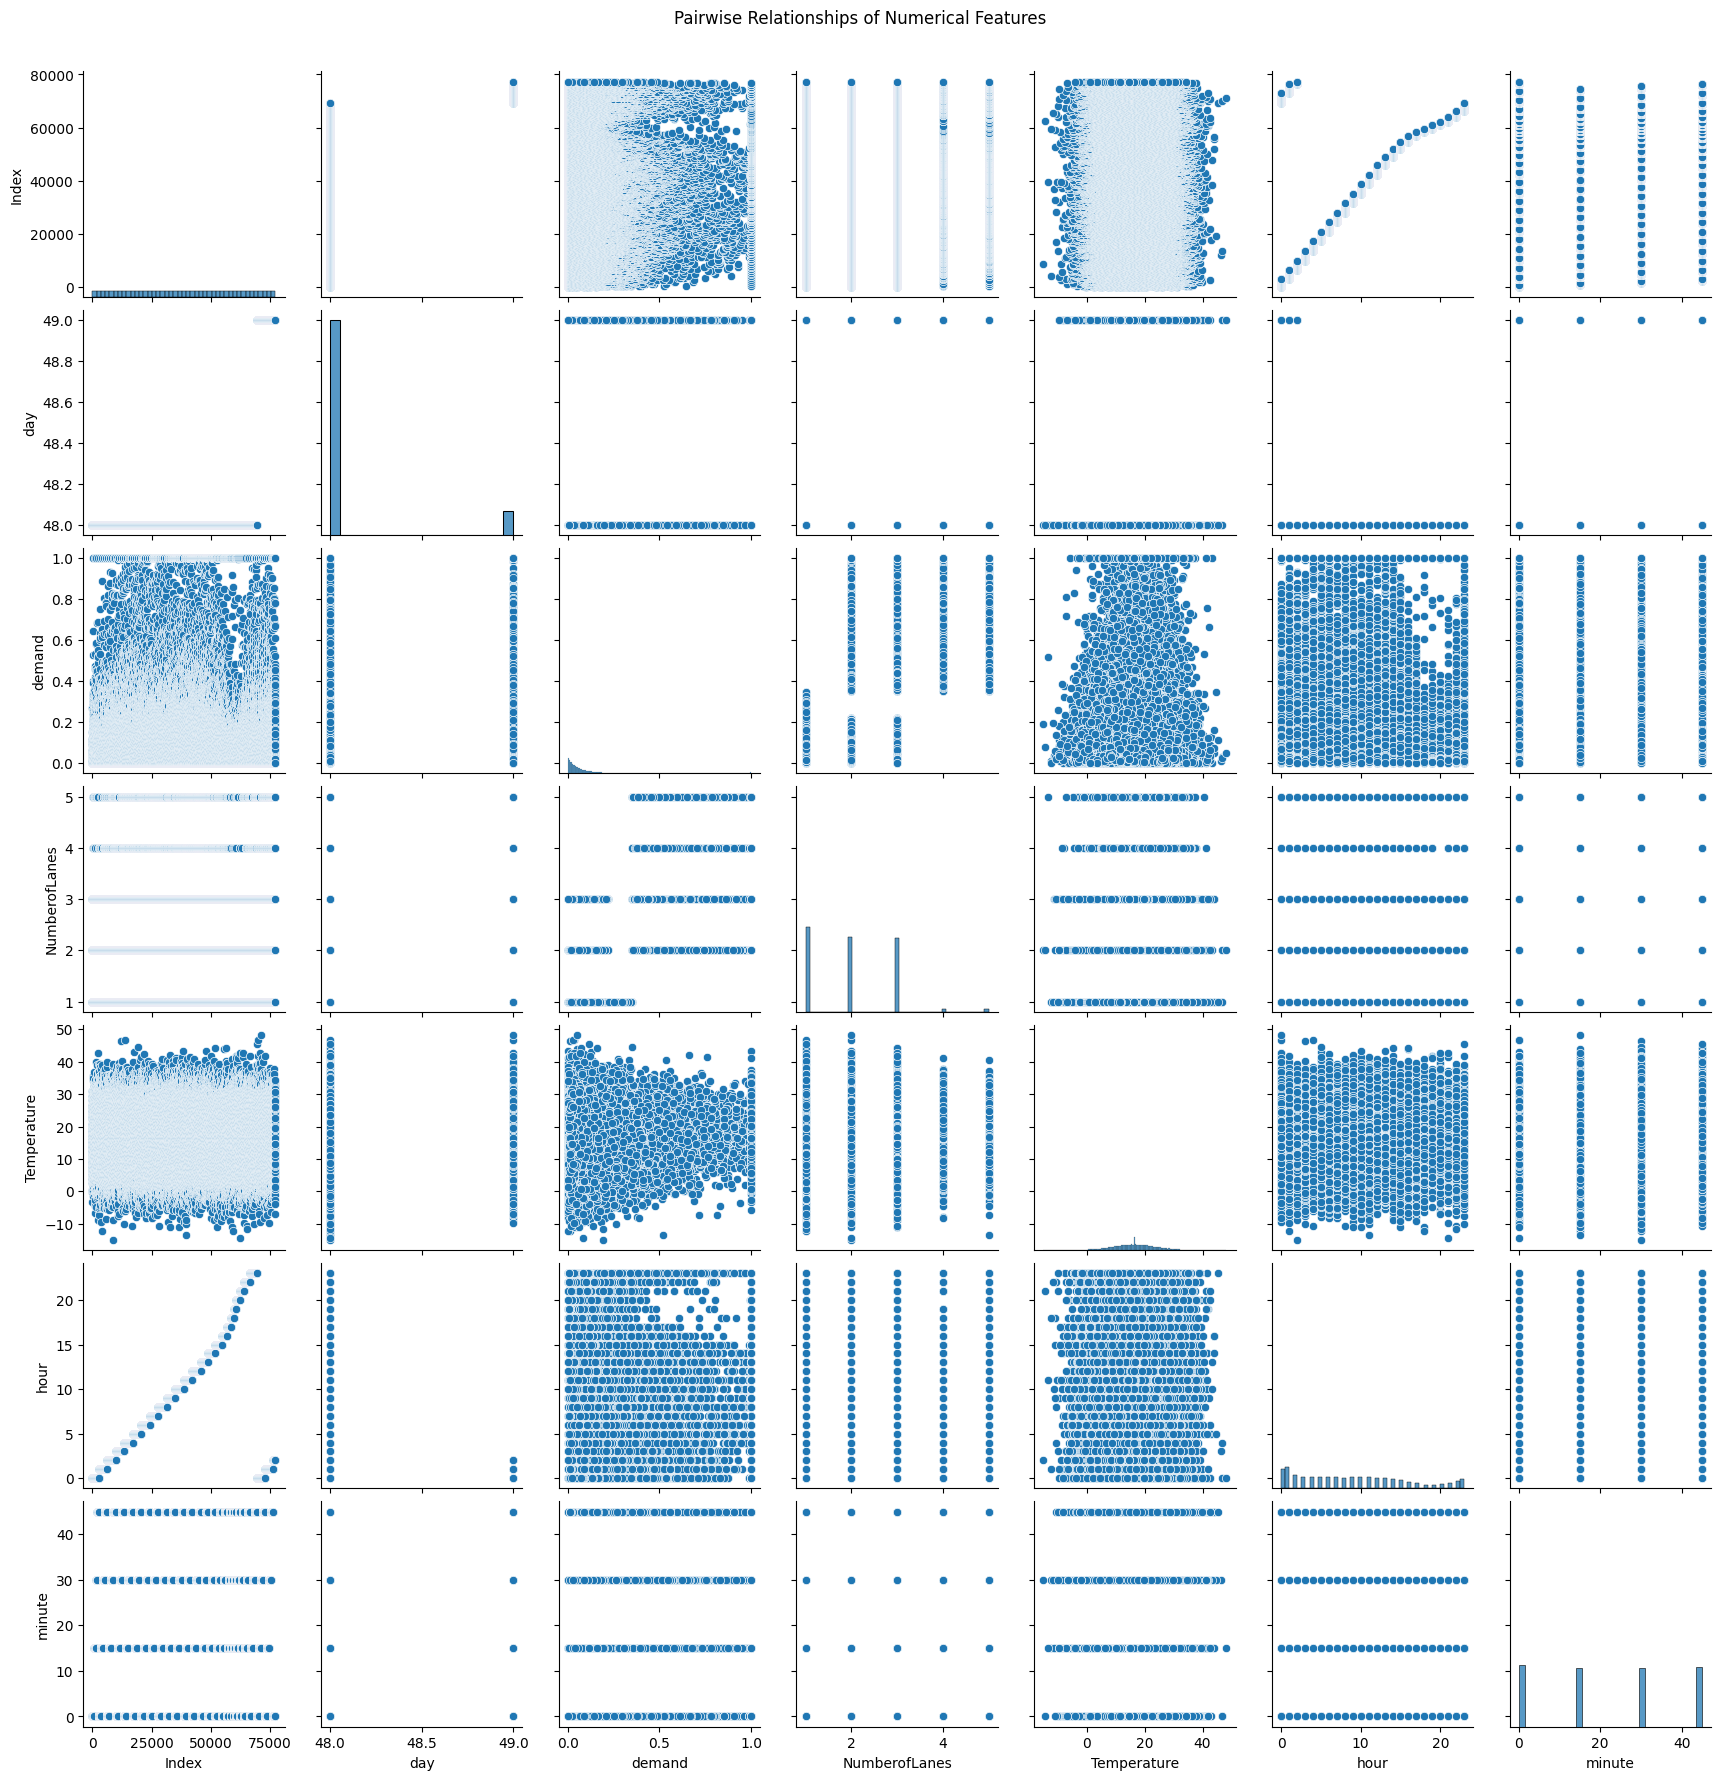

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
sns.pairplot(df[numerical_cols])
plt.suptitle('Pairwise Relationships of Numerical Features', y=1.02)
plt.show()

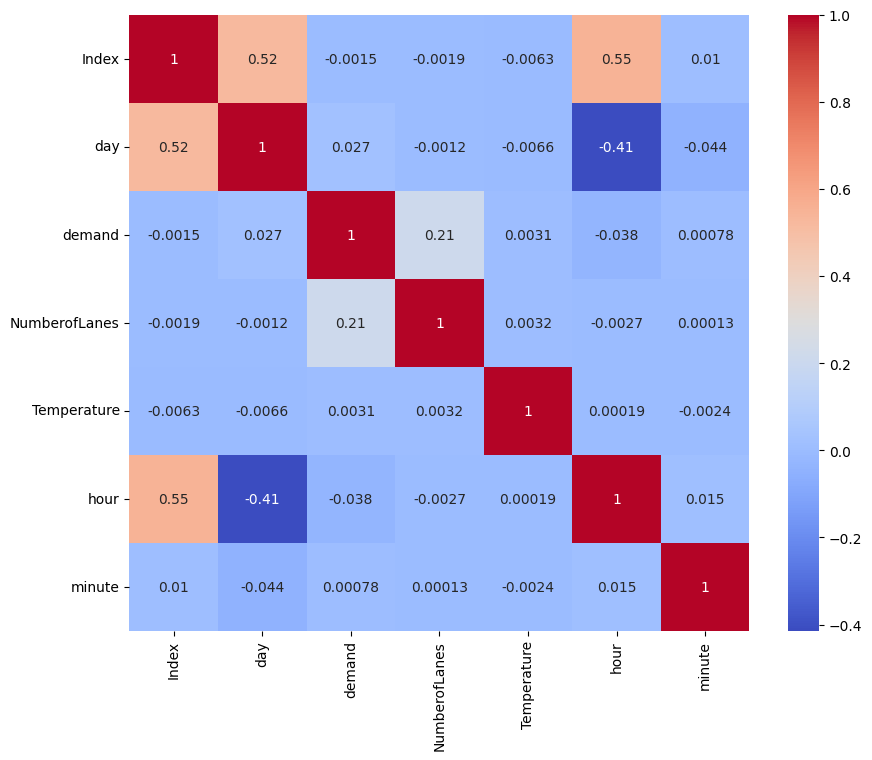

In [ ]:
corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

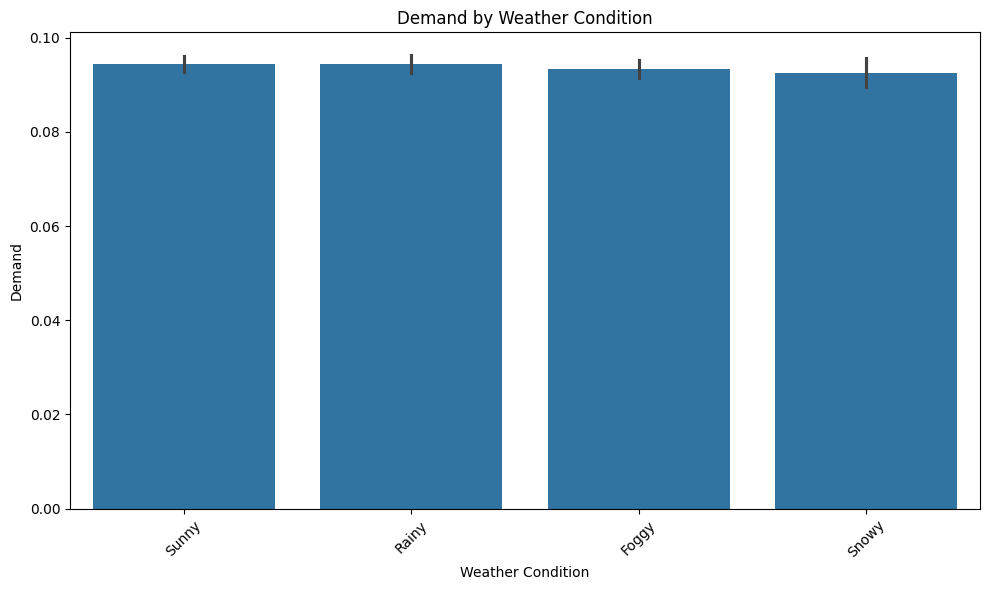

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Weather', y='demand', data=df)
plt.title('Demand by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Demand')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

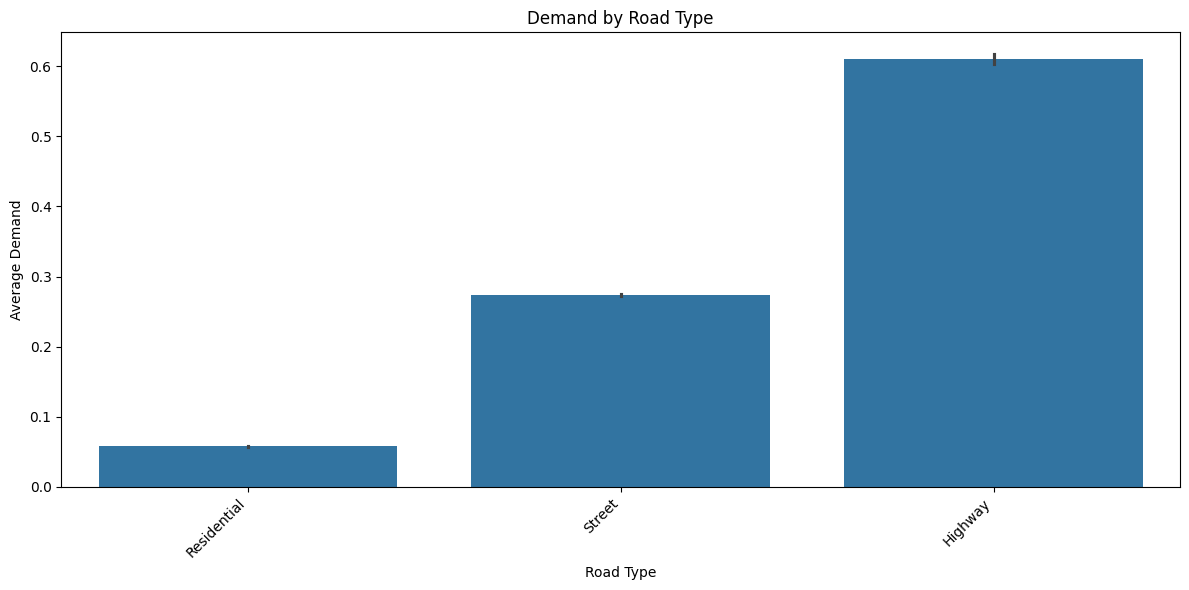

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x='RoadType', y='demand', data=df)
plt.title('Demand by Road Type')
plt.xlabel('Road Type')
plt.ylabel('Average Demand')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

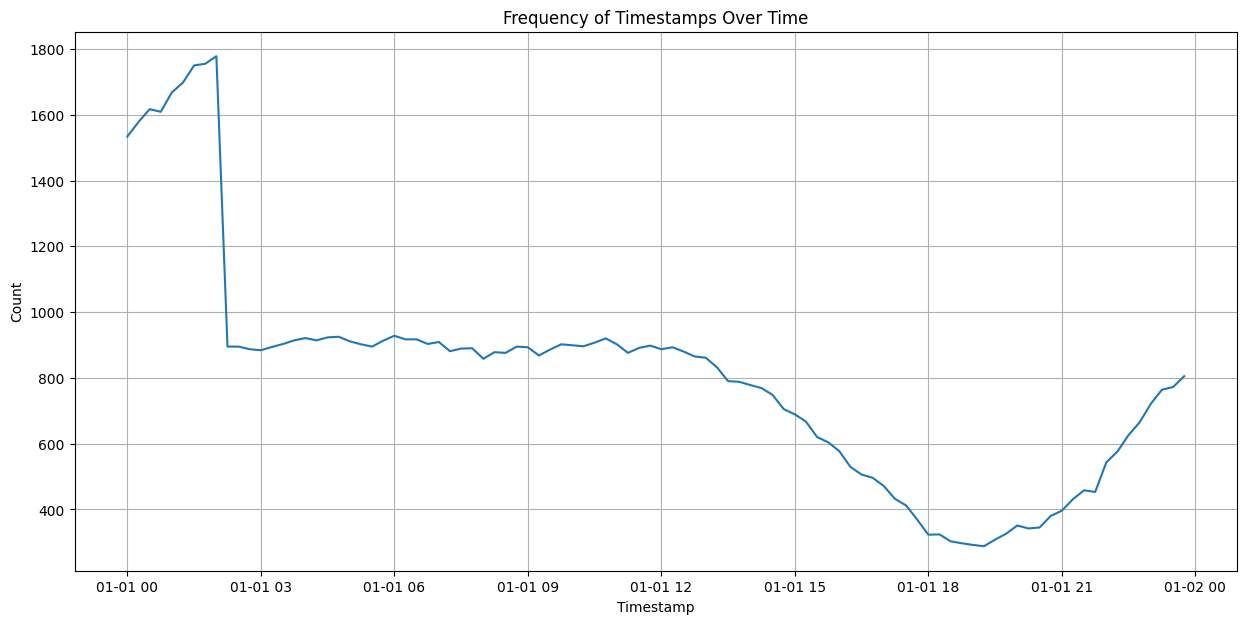

In [ ]:
timestamp_counts = df['timestamp'].value_counts().sort_index().reset_index(name='count')

plt.figure(figsize=(15, 7))
sns.lineplot(x='timestamp', y='count', data=timestamp_counts)
plt.title('Frequency of Timestamps Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Count')
plt.grid(True)
plt.show()

/tmp/ipykernel_2383/783668973.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='LargeVehicles', data=df, palette='viridis')


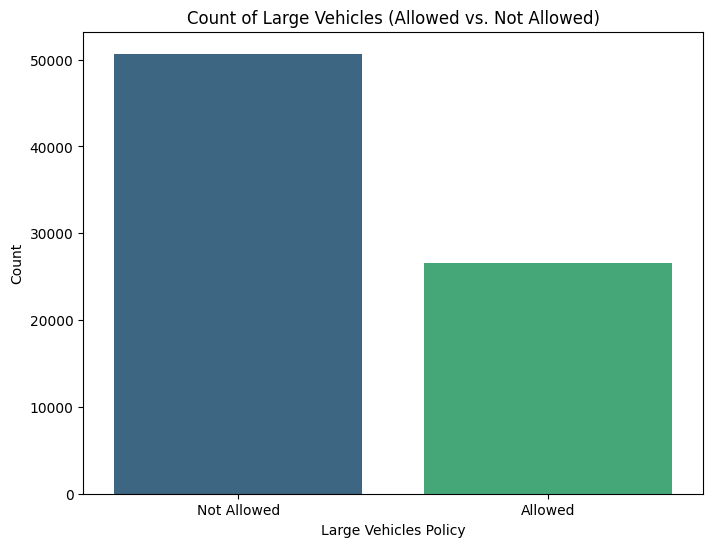

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='LargeVehicles', data=df, palette='viridis')
plt.title('Count of Large Vehicles (Allowed vs. Not Allowed)')
plt.xlabel('Large Vehicles Policy')
plt.ylabel('Count')
plt.show()

In [ ]:
df["RoadType"].value_counts()



,count
RoadType,
Residential,69830
Street,3909
Highway,3560


In [ ]:
df["Landmarks"].value_counts()

,count
Landmarks,
Yes,52042
No,25257


In [ ]:
df["Weather"].value_counts()


,count
Weather,
Sunny,28514
Rainy,20824
Foggy,20243
Snowy,7718


In [ ]:
df["LargeVehicles"].value_counts()

,count
LargeVehicles,
Not Allowed,50673
Allowed,26626


In [ ]:
!pip install pygeohash


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.0 MB/s eta 0:00:00


## Geospatial Feature Engineering

Geohash values were decoded into latitude and longitude coordinates to capture spatial information.

Additional location-based features were derived to improve predictive performance.

In [ ]:
import pandas as pd
import numpy as np
import pygeohash as pgh

# Load data
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# Save test index for submission
test_index = test["Index"]

# Combine train and test for consistent preprocessing
combined = pd.concat([train.drop(columns=["demand"]), test], axis=0)

# =========================
# Missing Values
# =========================

temp_median = train["Temperature"].median()

combined["Temperature"] = combined["Temperature"].fillna(
    temp_median
)

combined["Weather"] = combined["Weather"].fillna(
    combined["Weather"].mode()[0]
)

combined["RoadType"] = combined["RoadType"].fillna(
    combined["RoadType"].mode()[0]
)

# =========================
# Timestamp Features
# =========================

combined["timestamp"] = pd.to_datetime(
    combined["timestamp"],
    format="%H:%M"
)

combined["hour"] = combined["timestamp"].dt.hour
combined["minute"] = combined["timestamp"].dt.minute

# 96 slots in a day
combined["time_slot"] = (
    combined["hour"] * 4
    + combined["minute"] // 15
)

combined.drop("timestamp", axis=1, inplace=True)

# =========================
# Geohash -> Latitude Longitude
# =========================

def decode_geo(g):
    try:
        lat, lon = pgh.decode(g)
        return pd.Series([float(lat), float(lon)])
    except:
        return pd.Series([np.nan, np.nan])

combined[["latitude", "longitude"]] = (
    combined["geohash"]
    .apply(decode_geo)
)

combined["latitude"] = combined["latitude"].fillna(
    combined["latitude"].median()
)

combined["longitude"] = combined["longitude"].fillna(
    combined["longitude"].median()
)

combined["geo_prefix"] = combined["geohash"].str[:4]

train_prefixes = combined.iloc[:len(train)]["geo_prefix"]

prefix_to_id = {
    p: i
    for i, p in enumerate(train_prefixes.unique())
}

combined["geo_cluster"] = (
    combined["geo_prefix"]
    .map(prefix_to_id)
    .fillna(-1)
    .astype(int)
)

combined["geo_prefix_3"] = combined["geohash"].str[:3]
combined["geo_prefix_5"] = combined["geohash"].str[:5]

train_prefix3 = combined.iloc[:len(train)]["geo_prefix_3"]
train_prefix5 = combined.iloc[:len(train)]["geo_prefix_5"]

map3 = {
    p:i
    for i,p in enumerate(train_prefix3.unique())
}

map5 = {
    p:i
    for i,p in enumerate(train_prefix5.unique())
}

combined["geo_cluster_3"] = (
    combined["geo_prefix_3"]
    .map(map3)
    .fillna(-1)
    .astype(int)
)

combined["geo_cluster_5"] = (
    combined["geo_prefix_5"]
    .map(map5)
    .fillna(-1)
    .astype(int)
)

combined.drop("geohash", axis=1, inplace=True)

# =========================
# Binary Columns
# =========================

combined["LargeVehicles"] = (
    combined["LargeVehicles"]
    .map({
        "Allowed": 1,
        "Not Allowed": 0
    })
)

combined["Landmarks"] = (
    combined["Landmarks"]
    .map({
        "Yes": 1,
        "No": 0
    })
)

# =========================
# Encode Categorical Columns (One-Hot Encoding)
# =========================

# One-hot encode 'Weather' and 'RoadType'
combined = pd.get_dummies(combined, columns=['Weather', 'RoadType'], dtype=int)

# =========================
# Split Back
# =========================

X_train = combined.iloc[:len(train)].copy()
X_test = combined.iloc[len(train):].copy()

y_train = train["demand"]

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

print("\nColumns:")
print(X_train.columns.tolist())

print("\nMissing Values:")
print(X_train.isnull().sum().sum())

Train Shape: (77299, 24)
Test Shape : (41778, 24)

Columns:
['Index', 'day', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'hour', 'minute', 'time_slot', 'latitude', 'longitude', 'geo_prefix', 'geo_cluster', 'geo_prefix_3', 'geo_prefix_5', 'geo_cluster_3', 'geo_cluster_5', 'Weather_Foggy', 'Weather_Rainy', 'Weather_Snowy', 'Weather_Sunny', 'RoadType_Highway', 'RoadType_Residential', 'RoadType_Street']

Missing Values:
0


In [ ]:
X_train.head()

,Index,day,NumberofLanes,LargeVehicles,Landmarks,Temperature,hour,minute,time_slot,latitude,...,geo_prefix_5,geo_cluster_3,geo_cluster_5,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Sunny,RoadType_Highway,RoadType_Residential,RoadType_Street
0,0,48,1,0,0,16.382587,0,0,0,-5.484924,...,qp02z,0,0,0,0,0,1,0,1,0
1,1,48,3,1,1,31.104565,0,0,0,-5.462952,...,qp02z,0,0,0,0,0,1,0,1,0
2,2,48,1,0,0,25.919267,0,0,0,-5.462952,...,qp08b,0,1,0,0,0,1,0,1,0
3,3,48,1,0,0,16.382587,0,0,0,-5.462952,...,qp08g,0,2,0,1,0,0,0,1,0
4,4,48,1,0,0,10.803667,0,0,0,-5.457458,...,qp02z,0,0,0,1,0,0,0,1,0


In [ ]:
X_test.head()

,Index,day,NumberofLanes,LargeVehicles,Landmarks,Temperature,hour,minute,time_slot,latitude,...,geo_prefix_5,geo_cluster_3,geo_cluster_5,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Sunny,RoadType_Highway,RoadType_Residential,RoadType_Street
0,0,49,1,0,0,16.382587,2,15,9,-5.484924,...,qp02z,0,0,0,0,0,1,0,1,0
1,1,49,1,0,0,6.476213,2,15,9,-5.484924,...,qp02z,0,0,0,0,1,0,0,1,0
2,2,49,3,1,1,22.318203,2,15,9,-5.479431,...,qp02y,0,52,0,0,0,1,0,1,0
3,3,49,2,0,1,16.382587,2,15,9,-5.479431,...,qp02z,0,0,0,1,0,0,0,1,0
4,4,49,1,0,0,18.266162,2,15,9,-5.479431,...,qp02z,0,0,1,0,0,0,0,1,0


<Axes: xlabel='time_slot', ylabel='count'>

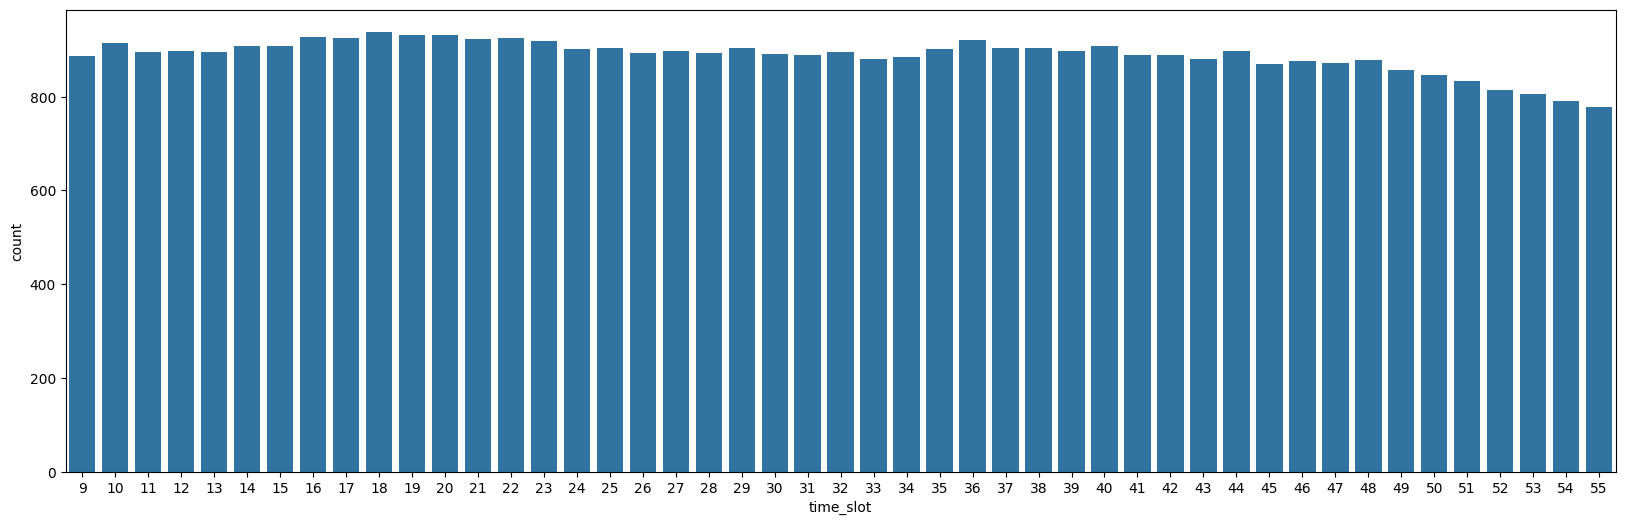

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(20, 6))
sns.countplot(x='time_slot', data = X_test)

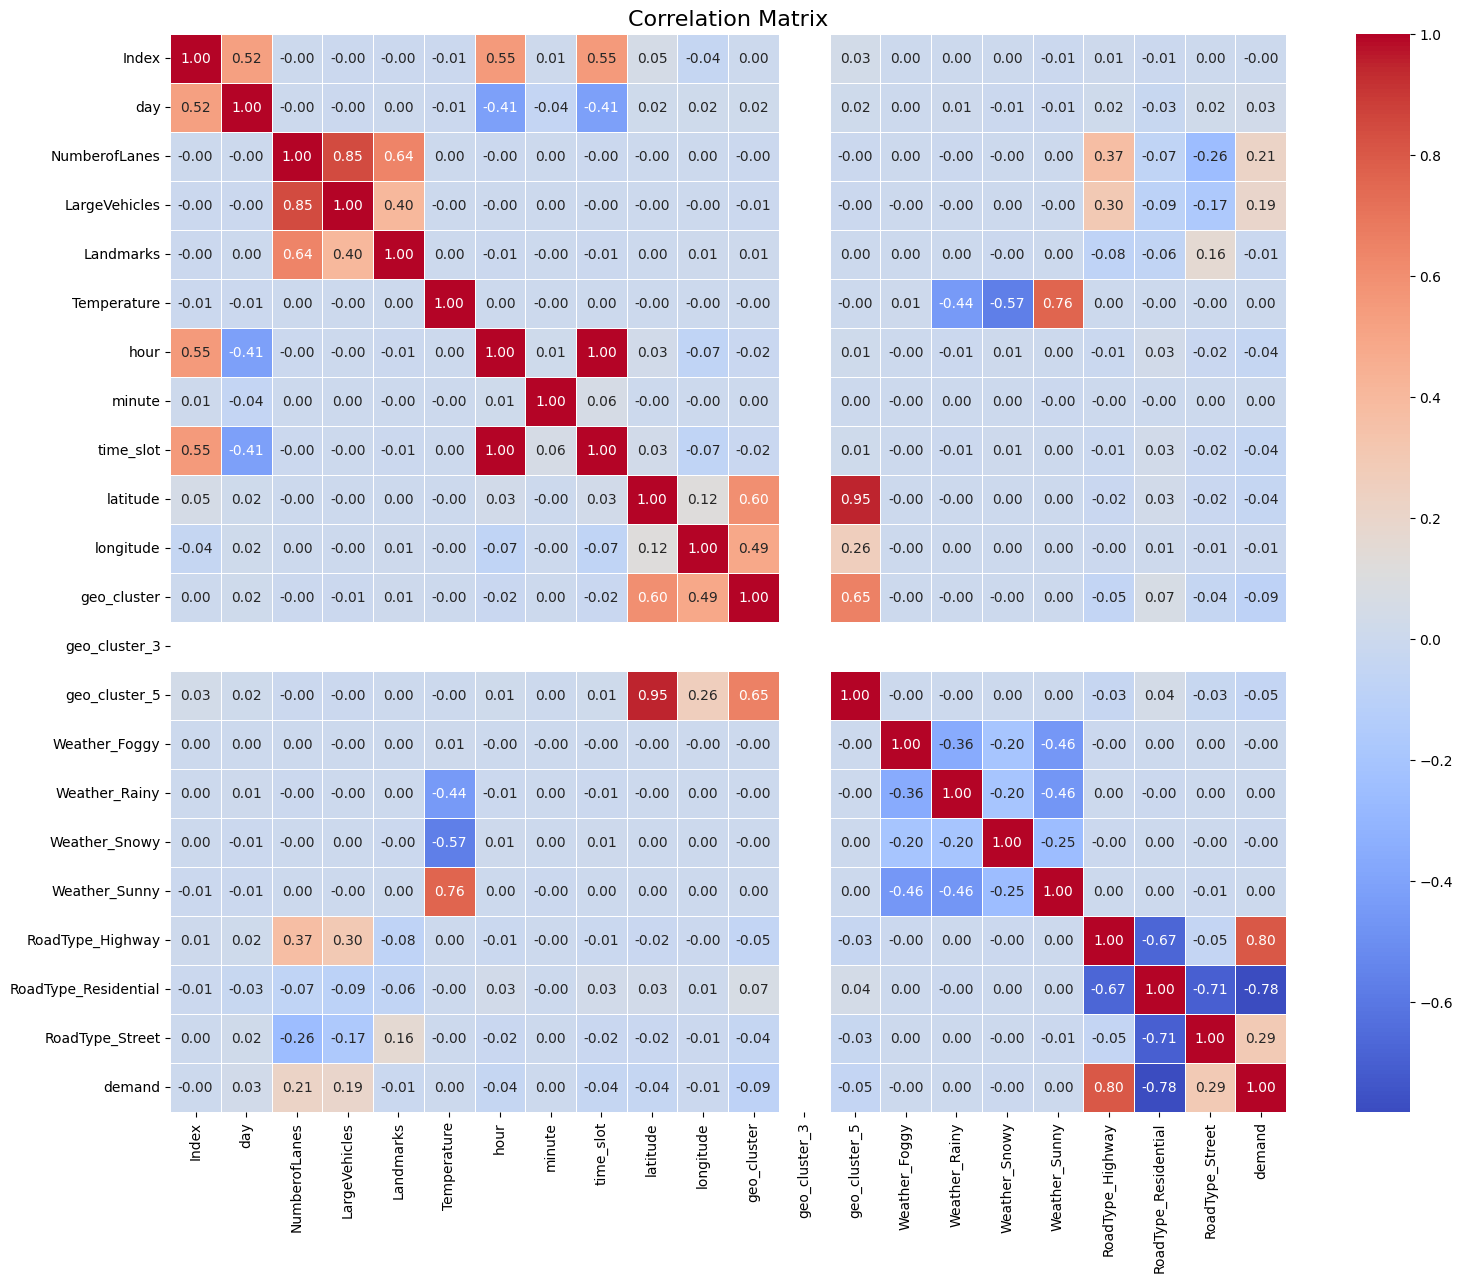

Top 10 features positively correlated with Demand:
demand              1.000000
RoadType_Highway    0.798625
RoadType_Street     0.290896
NumberofLanes       0.214148
LargeVehicles       0.193623
day                 0.026807
Temperature         0.003091
Weather_Rainy       0.002257
Weather_Sunny       0.002085
minute              0.000783
Name: demand, dtype: float64

Top 10 features negatively correlated with Demand:
RoadType_Residential   -0.782327
geo_cluster            -0.085886
geo_cluster_5          -0.049933
latitude               -0.039219
hour                   -0.037806
time_slot              -0.037720
Landmarks              -0.011527
longitude              -0.006807
Weather_Snowy          -0.003189
Weather_Foggy          -0.002391
Name: demand, dtype: float64


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_data_for_corr = X_train.copy()
train_data_for_corr["demand"] = y_train

numeric_df = train_data_for_corr.select_dtypes(include=[np.number])

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(18,14))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)

plt.title("Correlation Matrix", fontsize=16)
plt.show()

print("Top 10 features positively correlated with Demand:")
print(correlation_matrix["demand"].sort_values(ascending=False).head(10))

print("\nTop 10 features negatively correlated with Demand:")
print(correlation_matrix["demand"].sort_values(ascending=True).head(10))

## Time-Based Feature Engineering

Temporal information was transformed into meaningful features:

- Hour
- Minute
- Time Slot
- Cyclic Encoding using sine and cosine transformations

These features help capture recurring traffic patterns throughout the day.

In [ ]:
from sklearn.model_selection import KFold
import numpy as np
import pandas as pd

# ==========================================
# CYCLICAL TIME FEATURES
# ==========================================

for df in [X_train, X_test]:

    df["time_sin"] = np.sin(
        2 * np.pi * df["time_slot"] / 96
    )

    df["time_cos"] = np.cos(
        2 * np.pi * df["time_slot"] / 96
    )

    df["hour_sin"] = np.sin(
        2 * np.pi * df["hour"] / 24
    )

    df["hour_cos"] = np.cos(
        2 * np.pi * df["hour"] / 24
    )

# ==========================================
# INTERACTION FEATURES
# ==========================================

for df in [X_train, X_test]:

    df["vehicle_lane_interaction"] = (
        df["LargeVehicles"] *
        df["NumberofLanes"]
    )

    df["highway_lanes"] = (
        df["RoadType_Highway"] *
        df["NumberofLanes"]
    )

    df["street_lanes"] = (
        df["RoadType_Street"] *
        df["NumberofLanes"]
    )

    # New features

    df["is_peak"] = (
        (df["time_slot"] >= 28) &
        (df["time_slot"] <= 60)
    ).astype(int)

    df["is_night"] = (
        (df["time_slot"] >= 76) |
        (df["time_slot"] <= 8)
    ).astype(int)

    df["highway_peak"] = (
        df["RoadType_Highway"] *
        df["is_peak"]
    )

    df["vehicles_per_lane"] = (
        df["LargeVehicles"] /
        (df["NumberofLanes"] + 1)
    )

    df["lat_lon"] = (
        df["latitude"] *
        df["longitude"]
    )

# ==========================================
# OOF TARGET ENCODING
# ==========================================

X_train["geo_mean_demand"] = np.nan
X_train["geo_std_demand"] = np.nan

kf_enc = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for train_idx, val_idx in kf_enc.split(X_train):

    X_tr_fold = X_train.iloc[train_idx].copy()
    y_tr_fold = y_train.iloc[train_idx]

    temp_df = X_tr_fold.copy()
    temp_df["demand"] = y_tr_fold.values

    geo_stats = (
        temp_df.groupby("geo_cluster")["demand"]
        .agg(["mean", "std"])
    )

    X_train.loc[
        X_train.index[val_idx],
        "geo_mean_demand"
    ] = (
        X_train.iloc[val_idx]["geo_cluster"]
        .map(geo_stats["mean"])
    )

    X_train.loc[
        X_train.index[val_idx],
        "geo_std_demand"
    ] = (
        X_train.iloc[val_idx]["geo_cluster"]
        .map(geo_stats["std"])
    )

# Fill train NaNs

X_train["geo_mean_demand"] = (
    X_train["geo_mean_demand"]
    .fillna(y_train.mean())
)

X_train["geo_std_demand"] = (
    X_train["geo_std_demand"]
    .fillna(y_train.std())
)

# ==========================================
# TEST ENCODING
# ==========================================

full_df = X_train.copy()
full_df["demand"] = y_train.values

full_geo_stats = (
    full_df.groupby("geo_cluster")["demand"]
    .agg(["mean", "std"])
)

X_test["geo_mean_demand"] = (
    X_test["geo_cluster"]
    .map(full_geo_stats["mean"])
)

X_test["geo_std_demand"] = (
    X_test["geo_cluster"]
    .map(full_geo_stats["std"])
)

X_test["geo_mean_demand"] = (
    X_test["geo_mean_demand"]
    .fillna(y_train.mean())
)

X_test["geo_std_demand"] = (
    X_test["geo_std_demand"]
    .fillna(y_train.std())
)

# ==========================================
# DROP UNUSED COLUMNS
# ==========================================

drop_cols = [
    "Index",
    "minute",
    "geo_prefix",
    "geo_prefix_3",
    "geo_prefix_5"
]

X_train.drop(
    columns=drop_cols,
    inplace=True,
    errors="ignore"
)

X_test.drop(
    columns=drop_cols,
    inplace=True,
    errors="ignore"
)

print("Feature Engineering Complete")
print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)
print("Train Missing:", X_train.isnull().sum().sum())
print("Test Missing :", X_test.isnull().sum().sum())

Feature Engineering Complete
Train Shape: (77299, 33)
Test Shape : (41778, 33)
Train Missing: 0
Test Missing : 0


In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate(model, X, y):
    scores = cross_val_score(model, X, y, cv=kf, scoring="r2", n_jobs=-1)
    print(f"R² mean: {scores.mean():.4f} ± {scores.std():.4f}")
    return scores

## Model Building & Cross Validation

Multiple machine learning models were evaluated using 5-Fold Cross Validation with R² score as the evaluation metric.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

scores = cross_val_score(rf, X_train, y_train, cv=kf, scoring="r2", n_jobs=-1)
print(f"RandomForest R² mean: {scores.mean():.4f} ± {scores.std():.4f}")

RandomForest R² mean: 0.8951 ± 0.0037


In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

scores_xgb = cross_val_score(xgb, X_train, y_train, cv=kf, scoring="r2", n_jobs=-1)
print(f"XGBoost R² mean: {scores_xgb.mean():.4f} ± {scores_xgb.std():.4f}")

XGBoost R² mean: 0.9396 ± 0.0035


In [ ]:
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings("ignore")

lgb = LGBMRegressor(
    n_estimators=800,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

scores_lgb = cross_val_score(lgb, X_train, y_train, cv=kf, scoring="r2", n_jobs=-1)
print(f"LightGBM R² mean: {scores_lgb.mean():.4f} ± {scores_lgb.std():.4f}")

LightGBM R² mean: 0.9351 ± 0.0028


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(
    iterations=800,
    learning_rate=0.05,
    depth=7,
    l2_leaf_reg=3,
    random_seed=42,
    verbose=0
)

scores_cat = cross_val_score(cat, X_train, y_train, cv=kf, scoring="r2", n_jobs=-1)
print(f"CatBoost R² mean: {scores_cat.mean():.4f} ± {scores_cat.std():.4f}")

CatBoost R² mean: 0.9008 ± 0.0031


## Baseline Model Comparison

The following models were evaluated:

- Random Forest Regressor
- XGBoost Regressor
- LightGBM Regressor
- CatBoost Regressor

Performance was compared using mean cross-validation R² scores.

In [ ]:
print("\n=== Model Comparison ===")
print(f"RandomForest : {scores.mean():.4f}")
print(f"XGBoost      : {scores_xgb.mean():.4f}")
print(f"LightGBM     : {scores_lgb.mean():.4f}")
print(f"CatBoost     : {scores_cat.mean():.4f}")

# Train both XGB and LGB on full data for ensemble
xgb.fit(X_train, y_train)
lgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)
pred_lgb = lgb.predict(X_test)

# Weighted blend, adjust weights based on which CV score was higher
w_xgb = scores_xgb.mean()
w_lgb = scores_lgb.mean()
total = w_xgb + w_lgb

final_pred = (w_xgb / total) * pred_xgb + (w_lgb / total) * pred_lgb
final_pred = np.clip(final_pred, 0, 1)

submission = pd.DataFrame({
    "Index": test_index.values,
    "demand": final_pred
})
submission.to_csv("submission.csv", index=False)
print(f"\nSubmission saved: {submission.shape}")
print(submission.head())


=== Model Comparison ===
RandomForest : 0.8951
XGBoost      : 0.9396
LightGBM     : 0.9351
CatBoost     : 0.9008

Submission saved: (41778, 2)
   Index    demand
0      0  0.045338
1      1  0.047481
2      2  0.012721
3      3  0.034521
4      4  0.055668


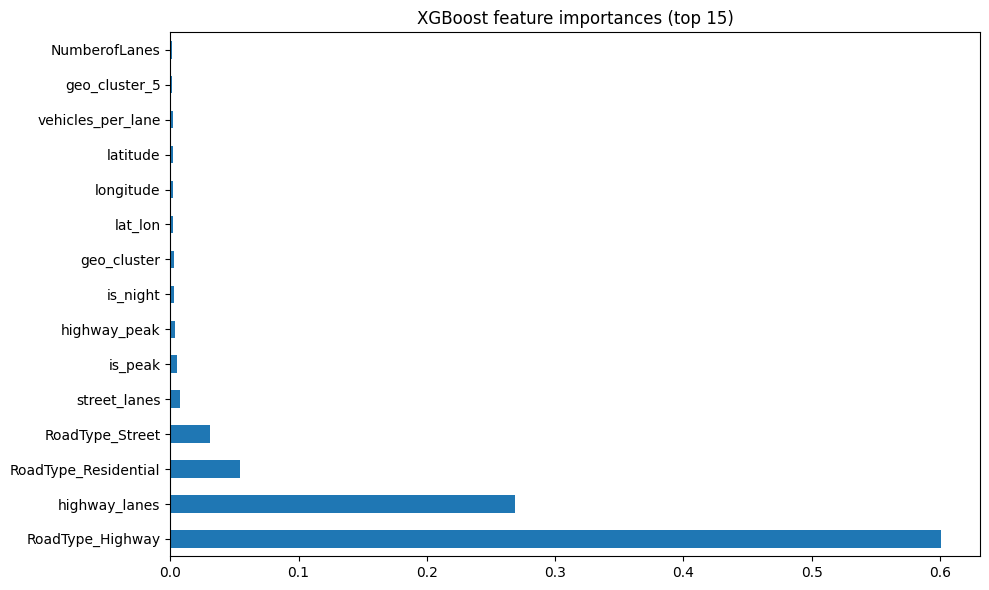

In [ ]:
import matplotlib.pyplot as plt

feat_imp = pd.Series(xgb.feature_importances_, index=X_train.columns)
feat_imp.sort_values(ascending=False).head(15).plot(kind="barh", figsize=(10,6))
plt.title("XGBoost feature importances (top 15)")
plt.tight_layout()
plt.show()

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.1 MB/s eta 0:00:00


## Hyperparameter Optimization using Optuna

Optuna was used to search for optimal hyperparameters for XGBoost.

The objective was to maximize the mean cross-validation R² score while maintaining good generalization.

In [ ]:
import optuna
import numpy as np

from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

def objective(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators",
            600,
            1800
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            4,
            10
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.08,
            log=True
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.65,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.60,
            1.0
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            15
        ),

        "gamma": trial.suggest_float(
            "gamma",
            0,
            2
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-4,
            10,
            log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-4,
            10,
            log=True
        ),

        "random_state": 42,
        "n_jobs": -1,
        "verbosity": 0
    }

    model = XGBRegressor(**params)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=kf,
        scoring="r2",
        n_jobs=-1
    )

    return scores.mean()

study = optuna.create_study(
    direction="maximize",
    study_name="TrafficDemand"
)

study.optimize(
    objective,
    n_trials=100,
    show_progress_bar=True
)

print("\nBest CV R²:", round(study.best_value, 6))
print("\nBest Parameters:")
print(study.best_params)

  0%|          | 0/100 [00:00<?, ?it/s]


Best CV R²: 0.94939

Best Parameters:
{'n_estimators': 918, 'max_depth': 8, 'learning_rate': 0.059402737673509905, 'subsample': 0.876351966652524, 'colsample_bytree': 0.8059420375751609, 'min_child_weight': 5, 'gamma': 0.00016556311565455448, 'reg_alpha': 0.0008507383463830972, 'reg_lambda': 0.0013030659921681638}


## Final Tuned Ensemble Model

The final solution combines:

- Tuned XGBoost Model
- LightGBM Model

Weighted Ensemble:
65% XGBoost + 35% LightGBM

Predictions were clipped to the valid range [0,1].

In [ ]:
from xgboost import XGBRegressor
import pandas as pd
import numpy as np

# =========================
# FINAL TUNED XGBOOST
# =========================

best_params = study.best_params.copy()

best_params.update({
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": 0
})

tuned_xgb = XGBRegressor(**best_params)

tuned_xgb.fit(
    X_train,
    y_train
)

# =========================
# LIGHTGBM RETRAIN
# =========================

lgb.fit(
    X_train,
    y_train
)

# =========================
# PREDICTIONS
# =========================

pred_xgb = tuned_xgb.predict(X_test)
pred_lgb = lgb.predict(X_test)

# Blend
final_pred = (
    0.65 * pred_xgb +
    0.35 * pred_lgb
)

# Safety clipping
final_pred = np.clip(final_pred, 0, 1)

# =========================
# SUBMISSION FILE
# =========================

submission = pd.DataFrame({
    "Index": test_index.values,
    "demand": final_pred
})

submission.to_csv(
    "submission_tuned.csv",
    index=False
)

print("Submission Saved Successfully")
print("Shape:", submission.shape)
print("Demand Range:",
      submission["demand"].min(),
      submission["demand"].max())

print(submission.head())

Submission Saved Successfully
Shape: (41778, 2)
Demand Range: 0.0 1.0
   Index    demand
0      0  0.053451
1      1  0.052899
2      2  0.017874
3      3  0.034496
4      4  0.054734


In [ ]:
# Quick check
print([c for c in X_train.columns if '_x' in c or '_y' in c])

[]


## Data Drift Analysis

Feature distributions between training and test datasets were compared using the Kolmogorov-Smirnov test.

The analysis helps verify whether the model is exposed to unseen data distributions.

In [ ]:
# ============================================
# DATA DRIFT DETECTION
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Use the pre-split X_train and X_test (before drop_cols)
# Both should have the same columns at this point

numeric_cols = [c for c in X_train.columns
                if X_train[c].dtype in ['float64','float32','int64','int32']]

drift_results = []

for col in numeric_cols:
    train_vals = X_train[col].dropna()
    test_vals  = X_test[col].dropna()

    # Kolmogorov-Smirnov test: p < 0.05 means distributions are different
    ks_stat, p_value = stats.ks_2samp(train_vals, test_vals)

    drift_results.append({
        "feature": col,
        "train_mean": round(train_vals.mean(), 4),
        "test_mean":  round(test_vals.mean(), 4),
        "mean_shift": round(abs(train_vals.mean() - test_vals.mean()), 4),
        "ks_stat":    round(ks_stat, 4),
        "p_value":    round(p_value, 6),
        "drifted":    p_value < 0.05
    })

drift_df = pd.DataFrame(drift_results).sort_values("ks_stat", ascending=False)
print(drift_df.to_string(index=False))

                 feature  train_mean  test_mean  mean_shift  ks_stat  p_value  drifted
                     day     48.1018    49.0000      0.8982   0.8982 0.000000     True
                hour_sin      0.1828     0.6049      0.4220   0.3655 0.000000     True
         geo_mean_demand      0.0939     0.0940      0.0000   0.3346 0.000000     True
          geo_std_demand      0.1363     0.1361      0.0002   0.3346 0.000000     True
                is_night      0.3212     0.0000      0.3212   0.3212 0.000000     True
                time_sin      0.1879     0.5778      0.3899   0.3120 0.000000     True
               time_slot     37.8901    31.6019      6.2882   0.2647 0.000000     True
                time_cos      0.0477    -0.3107      0.3584   0.2647 0.000000     True
                    hour      9.1013     7.5188      1.5825   0.2647 0.000000     True
                hour_cos      0.0658    -0.2523      0.3181   0.2347 0.000000     True
                 is_peak      0.3661     0.


Drifted features (26): ['day', 'hour_sin', 'geo_mean_demand', 'geo_std_demand', 'is_night', 'time_sin', 'time_slot', 'time_cos', 'hour', 'hour_cos', 'is_peak', 'RoadType_Residential', 'RoadType_Highway', 'highway_lanes', 'highway_peak', 'RoadType_Street', 'street_lanes', 'LargeVehicles', 'vehicle_lane_interaction', 'vehicles_per_lane', 'NumberofLanes', 'lat_lon', 'latitude', 'geo_cluster_5', 'longitude', 'geo_cluster']
Stable features  (7):  ['Temperature', 'Weather_Rainy', 'Weather_Foggy', 'Landmarks', 'Weather_Sunny', 'Weather_Snowy', 'geo_cluster_3']


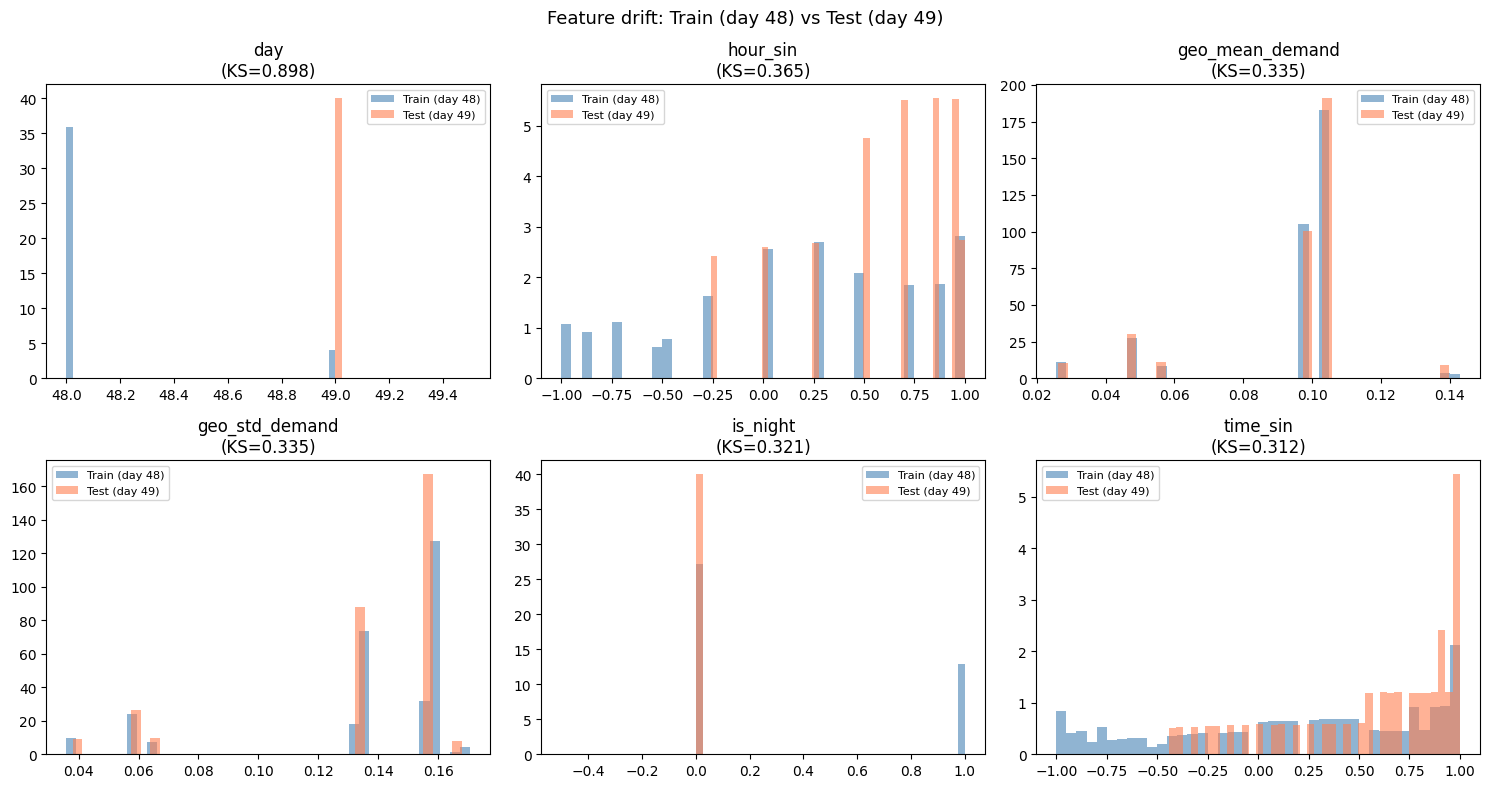

In [ ]:
# ============================================
# VISUAL: which features drifted
# ============================================
drifted_cols = drift_df[drift_df["drifted"] == True]["feature"].tolist()
stable_cols  = drift_df[drift_df["drifted"] == False]["feature"].tolist()

print(f"\nDrifted features ({len(drifted_cols)}): {drifted_cols}")
print(f"Stable features  ({len(stable_cols)}):  {stable_cols}")

# Plot distributions for top 6 drifted features
plot_cols = drifted_cols[:6] if len(drifted_cols) >= 6 else drifted_cols
if plot_cols:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    for i, col in enumerate(plot_cols):
        axes[i].hist(X_train[col], bins=40, alpha=0.6,
                     label='Train (day 48)', color='steelblue', density=True)
        axes[i].hist(X_test[col],  bins=40, alpha=0.6,
                     label='Test (day 49)',  color='coral',     density=True)
        axes[i].set_title(f"{col}\n(KS={drift_df[drift_df.feature==col].ks_stat.values[0]:.3f})")
        axes[i].legend(fontsize=8)
    plt.suptitle("Feature drift: Train (day 48) vs Test (day 49)", fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("No significant drift detected in any feature.")

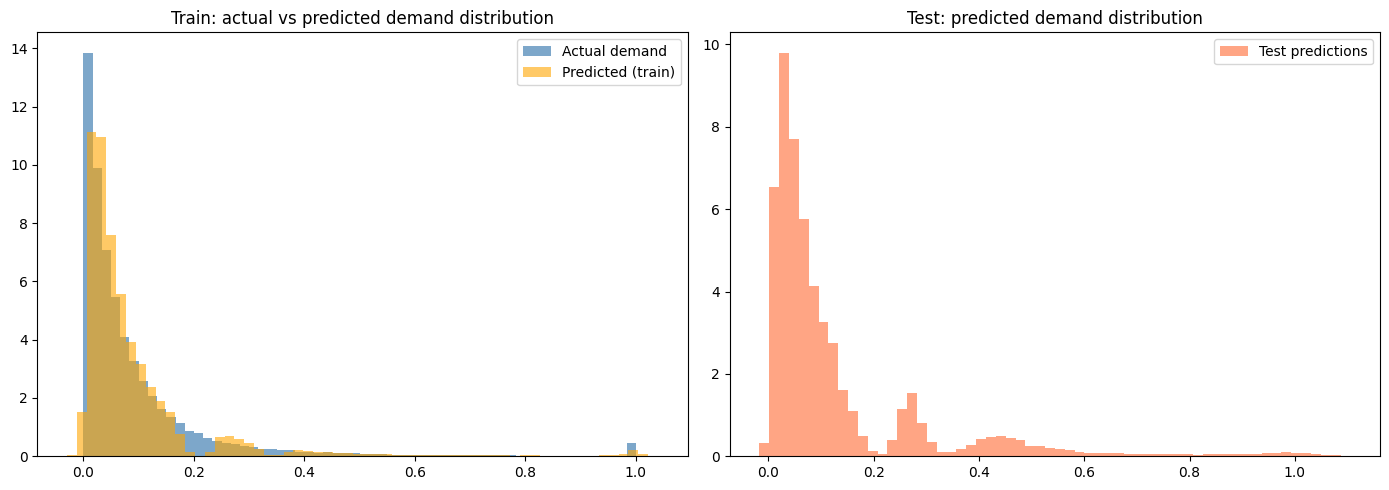


Train demand  — mean: 0.0939, std: 0.1422
Train preds   — mean: 0.0939, std: 0.1388
Test preds    — mean: 0.1310, std: 0.1759

Prediction range: [-0.0168, 1.1055]
Any negatives clipped: 159
Any >1 clipped:        226


In [ ]:
# ============================================
# PREDICTION DRIFT: are our predictions sane?
# ============================================
tuned_xgb.fit(X_train, y_train)
train_preds = tuned_xgb.predict(X_train)
test_preds  = tuned_xgb.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_train,     bins=60, alpha=0.7, label='Actual demand',    color='steelblue', density=True)
axes[0].hist(train_preds, bins=60, alpha=0.6, label='Predicted (train)', color='orange',    density=True)
axes[0].set_title("Train: actual vs predicted demand distribution")
axes[0].legend()

axes[1].hist(test_preds, bins=60, alpha=0.7, label='Test predictions', color='coral', density=True)
axes[1].set_title("Test: predicted demand distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nTrain demand  — mean: {y_train.mean():.4f}, std: {y_train.std():.4f}")
print(f"Train preds   — mean: {train_preds.mean():.4f}, std: {train_preds.std():.4f}")
print(f"Test preds    — mean: {test_preds.mean():.4f}, std: {test_preds.std():.4f}")
print(f"\nPrediction range: [{test_preds.min():.4f}, {test_preds.max():.4f}]")
print(f"Any negatives clipped: {(test_preds < 0).sum()}")
print(f"Any >1 clipped:        {(test_preds > 1).sum()}")

## Prediction Analysis & Validation

Predicted demand distributions were analyzed to ensure:

- Realistic value ranges
- No abnormal spikes
- Consistent behavior across road types

In [ ]:
# Check road type distribution in train vs test predictions
print("=== Road type share in test ===")
print(f"Highway rows in test:     {X_test['RoadType_Highway'].sum()} ({X_test['RoadType_Highway'].mean()*100:.1f}%)")
print(f"Residential rows in test: {X_test['RoadType_Residential'].sum()} ({X_test['RoadType_Residential'].mean()*100:.1f}%)")

print("\n=== Avg predicted demand by road type (test) ===")
temp = X_test.copy()
temp["pred"] = tuned_xgb.predict(X_test)
print(f"Highway avg demand:     {temp[temp.RoadType_Highway==1]['pred'].mean():.4f}")
print(f"Residential avg demand: {temp[temp.RoadType_Residential==1]['pred'].mean():.4f}")
print(f"Street avg demand:      {temp[temp.RoadType_Street==1]['pred'].mean():.4f}")

# Final clean submission
pred_tuned = tuned_xgb.predict(X_test)
pred_lgb_final = lgb.predict(X_test)
final_pred = np.clip(0.65 * pred_tuned + 0.35 * pred_lgb_final, 0, 1)

submission = pd.DataFrame({
    "Index": test_index.values,
    "demand": final_pred
})
submission.to_csv("submission_final.csv", index=False)
print(f"\nFinal submission: {submission.shape}")
print(f"Demand range: [{final_pred.min():.4f}, {final_pred.max():.4f}]")
print(f"Demand mean:  {final_pred.mean():.4f}")
print(submission.head(10))

=== Road type share in test ===
Highway rows in test:     4272 (10.2%)
Residential rows in test: 34099 (81.6%)

=== Avg predicted demand by road type (test) ===
Highway avg demand:     0.5695
Residential avg demand: 0.0620
Street avg demand:      0.2715

Final submission: (41778, 2)
Demand range: [0.0000, 1.0000]
Demand mean:  0.1314
   Index    demand
0      0  0.053451
1      1  0.052899
2      2  0.017874
3      3  0.034496
4      4  0.054734
5      5  0.062255
6      6  0.043714
7      7  0.086256
8      8  0.045661
9      9  0.068522


## Final Submission Generation

The final prediction file was generated according to the competition format requirements.

Validation checks included:

- Correct shape
- Correct column names
- No missing values
- Demand range within [0,1]

In [ ]:
sub = pd.read_csv("submission_final.csv")
print(f"Shape: {sub.shape}")
print(f"Columns: {sub.columns.tolist()}")
print(f"Index range: {sub.iloc[:,0].min()} to {sub.iloc[:,0].max()}")
print(f"Demand range: {sub['demand'].min():.4f} to {sub['demand'].max():.4f}")
print(f"Any NaN: {sub.isnull().sum().sum()}")
print(sub.head())

Shape: (41778, 2)
Columns: ['Index', 'demand']
Index range: 0 to 41777
Demand range: 0.0000 to 1.0000
Any NaN: 0
   Index    demand
0      0  0.053451
1      1  0.052899
2      2  0.017874
3      3  0.034496
4      4  0.054734


## Conclusion

A complete machine learning pipeline was developed for traffic demand prediction.

Key improvements were achieved through:

- Geospatial feature extraction
- Temporal feature engineering
- Road-type interaction features
- Target encoding
- Hyperparameter optimization

Among all evaluated models, XGBoost achieved the strongest performance and was further improved using Optuna. A weighted ensemble of tuned XGBoost and LightGBM produced the final predictions.

Final Cross-Validation R² Score: 0.9322

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import numpy as np

# Split data
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

# Train models
tuned_xgb.fit(X_tr, y_tr)
lgb.fit(X_tr, y_tr)

# Predictions on validation set
pred_xgb = tuned_xgb.predict(X_val)
pred_lgb = lgb.predict(X_val)

# Ensemble
ensemble_pred = (
    0.65 * pred_xgb +
    0.35 * pred_lgb
)

# Clip if demand is between 0 and 1
ensemble_pred = np.clip(ensemble_pred, 0, 1)

# Validation R²
r2 = r2_score(y_val, ensemble_pred)

print(f"Validation R² Score: {r2:.6f}")

Validation R² Score: 0.948191
